# Rain maps that can be dry

IDW spreads every wet link over its radius, so a link map is wet almost everywhere and its peaks are diluted.
Here a wet/dry decision is made first, from the same links (`core.maps.wet_area`):

- **masked**: plain IDW, set to zero where the distance-weighted share of wet links is below a cut `p`;
- **conditional**: IDW of the wet links only, with the same mask.

Scored on 16 simulated cases (against the truth) and on the 29 storms of `maps/multisensor`
(against the radar and held-out gauges). The numbers come from `python src/run.py synthetic|real|report`.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

sys.path.insert(0, str(Path.cwd().parent / "src"))
from core.geo import Grid
from core.maps import wet_area as wa
from core.maps.idw import idw_map
from core.viz_style import use_style
from wet_area import study
from wet_area.settings import EVENT_INPUTS, IDW, RESULTS_DIR

use_style()
syn = pd.read_csv(RESULTS_DIR / "synthetic.csv")
real = pd.read_csv(RESULTS_DIR / "real.csv")
len(syn), len(real)

(112, 812)

## Against the true field
Medians over the simulated cases. `war_ratio` is the map's wet fraction over the truth's; `peak_ratio` its 99th percentile over the truth's.

In [2]:
study.summary(syn, [])

,map,nrmse,corr,rel_bias,csi,far,war_ratio,peak_ratio
0,conditional p0.3,1.364,0.209,-0.015,0.881,0.089,1.053,0.425
1,conditional p0.5,1.378,0.196,-0.214,0.758,0.076,1.015,0.424
2,conditional p0.7,1.378,0.163,-0.340,0.593,0.061,0.776,0.384
3,idw,1.333,0.195,-0.276,0.889,0.104,1.086,0.379
4,masked p0.3,1.338,0.189,-0.323,0.881,0.089,1.053,0.379
5,masked p0.5,1.344,0.182,-0.353,0.758,0.076,1.015,0.379
6,masked p0.7,1.344,0.164,-0.375,0.593,0.061,0.776,0.379


## Against the radar and held-out gauges
The RNN links (the best retrieval) and the dynamic-baseline power law (the best power law).

In [3]:
s = study.summary(real, ["reference", "network", "retrieval"])
keep = s["map"].isin(["idw", "masked p0.5", "conditional p0.5"])
s[keep].pivot_table(index=["reference", "network", "retrieval"], columns="map",
                    values=["war_ratio", "far", "nrmse"]).round(3)

far                     \
map                            conditional p0.5    idw masked p0.5   
reference network    retrieval                                       
gauges    openmesh   dynamic              0.119  0.141       0.119   
                     rnn                  0.080  0.077       0.080   
          openmrg    dynamic              0.058  0.240       0.058   
                     rnn                  0.094  0.093       0.094   
          openrainer dynamic              0.229  0.309       0.226   
                     rnn                  0.214  0.239       0.211   
radar     openmesh   dynamic              0.089  0.103       0.089   
                     rnn                  0.059  0.064       0.059   
          openmrg    dynamic              0.102  0.189       0.101   
                     rnn                  0.108  0.111       0.107   
          openrainer dynamic              0.211  0.260       0.208   
                     rnn                  0.202  0.210       0.199   

                                          nrmse                     \
map                            conditional p0.5    idw masked p0.5   
reference network    retrieval                                       
gauges    openmesh   dynamic              1.355  1.217       1.216   
                     rnn                  0.810  0.810       0.812   
          openmrg    dynamic              3.192  3.190       3.188   
                     rnn                  0.842  0.843       0.844   
          openrainer dynamic              3.001  2.910       2.865   
                     rnn                  1.722  1.715       1.718   
radar     openmesh   dynamic              1.275  1.227       1.227   
                     rnn                  0.641  0.641       0.641   
          openmrg    dynamic              2.003  1.993       1.993   
                     rnn                  1.394  1.387       1.390   
          openrainer dynamic              2.624  2.561       2.536   
                     rnn                  1.454  1.450       1.452   

                                      war_ratio                     
map                            conditional p0.5    idw masked p0.5  
reference network    retrieval                                      
gauges    openmesh   dynamic              1.132  1.165       1.132  
                     rnn                  0.984  1.000       0.984  
          openmrg    dynamic              0.964  1.291       0.964  
                     rnn                  0.947  0.966       0.929  
          openrainer dynamic              1.054  1.231       1.048  
                     rnn                  1.060  1.092       1.055  
radar     openmesh   dynamic              1.076  1.111       1.076  
                     rnn                  1.007  1.042       0.998  
          openmrg    dynamic              0.970  1.120       0.967  
                     rnn                  0.982  1.015       0.980  
          openrainer dynamic              0.989  1.086       0.982  
                     rnn                  0.938  1.009       0.928

## One storm
Gothenburg, power-law links (dynamic baseline), the hour where the mask changes the map most.

2015-07-08 10:00:00 cells dried by the mask: 24%


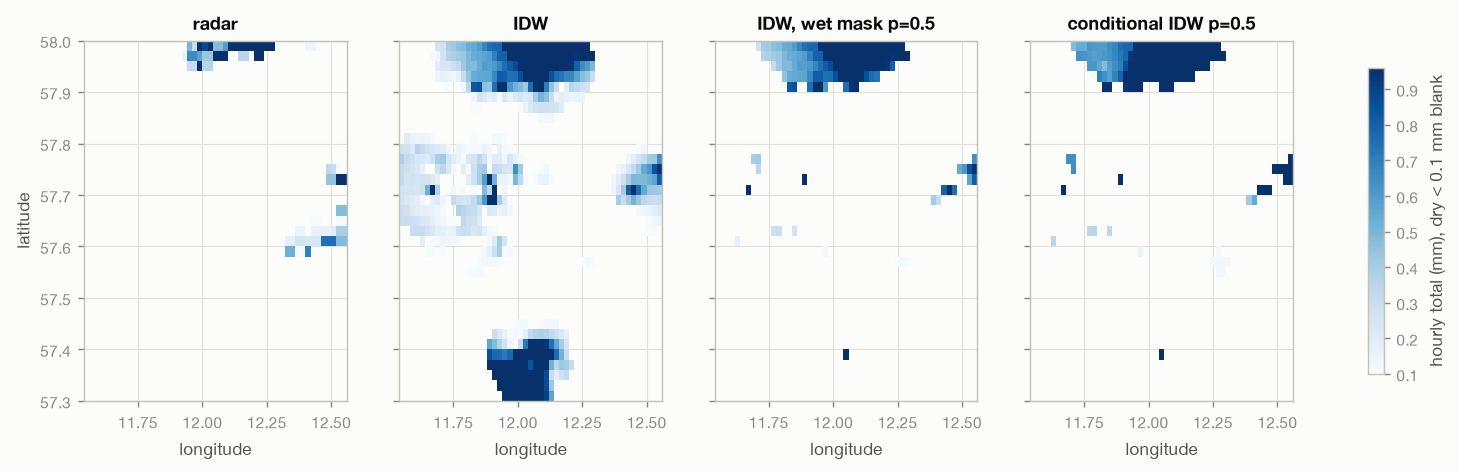

In [4]:
folder = EVENT_INPUTS / "openmrg_20150707T17"
radar = xr.open_dataarray(folder / "radar_0.nc").load()
links = xr.open_dataarray(folder / "links_dynamic.nc").load().transpose("link", "time")
grid = Grid(radar.lat.values, radar.lon.values)
full = {"IDW": idw_map(links, grid, **IDW),
        "IDW, wet mask p=0.5": wa.masked_idw(links, grid, p_cut=0.5, **IDW),
        "conditional IDW p=0.5": wa.conditional_idw(links, grid, p_cut=0.5, **IDW)}
dried = ((full["IDW"] >= 0.1) & (full["IDW, wet mask p=0.5"] < 0.1)).mean(("lat", "lon"))
t = dried.idxmax("time").values
maps = {"radar": radar.sel(time=t), **{k: v.sel(time=t) for k, v in full.items()}}
print(pd.Timestamp(t), f"cells dried by the mask: {float(dried.max()):.0%}")
vmax = float(np.nanquantile(maps["radar"], 0.99))
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, (name, m) in zip(axes, maps.items()):
    im = ax.pcolormesh(m.lon, m.lat, m.where(m >= 0.1), vmin=0.1, vmax=vmax, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("longitude")
axes[0].set_ylabel("latitude")
fig.colorbar(im, ax=axes, label="hourly total (mm), dry < 0.1 mm blank", shrink=0.85)
plt.show()

## What it shows

- **The mask fixes the wet area.** Plain IDW of power-law links is 12-29% too wet against the radar and gauges;
  with `p = 0.5` the wet fraction is within a few percent of the reference and false alarms fall (Gothenburg,
  at the gauges: FAR 0.24 to 0.06). The RNN links are already about right, so the mask changes little there.
- **It does not fix the amounts.** NRMSE and correlation move by about 1% or less: hourly error is in where the
  heavy rain is, not in the drizzle at the edges.
- **Conditional IDW does not bring the peaks back** (simulated: 99th percentile 0.38 to 0.42 of the truth's).
  Peaks are lost between links, which no interpolation of the same links recovers (`simulation/regimes`).
- `p = 0.5` is a sound default; `0.7` starts to miss real rain (CSI falls).